<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border: 2px solid lime; border-radius: 8px"; align = "center">
Project Name: Customer Churn Prediction System<br> Using "Telco Customer Dataset - IBM"</h3>



<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Methodology:</h3>

<h1 style = "background-color: #111; padding: 5px; font: bold 20px Times New Roman; color: blue";  align = "left">
                 BUSINESS PROBLEM<br>
                          ↓<br>
                 PROBLEM DEFINITION<br>
                          ↓<br>
                    DATA COLLECTION<br>
                          ↓<br>
                 DATA UNDERSTANDING<br>
                          ↓<br>
                  DATA QUALITY CHECK<br>
                          ↓<br>
                    DATA CLEANING<br>
                          ↓<br>
                  EXPLORATORY DATA ANALYSIS (EDA)<br>
                          ↓<br>
                STATISTICAL ANALYSIS<br>
                          ↓<br>
                  FEATURE ENGINEERING<br>
                          ↓<br>
               TRAIN / VALIDATION / TEST<br>
                          ↓<br>
                  DATA PREPROCESSING<br>
                          ↓<br>
                 BASELINE MODEL<br>
                          ↓<br>
              MACHINE LEARNING MODELS<br>
                          ↓<br>
                 MODEL EVALUATION<br>
                          ↓<br>
               HYPERPARAMETER TUNING<br>
                          ↓<br>
                 MODEL INTERPRETATION
                       (SHAP)<br>
                          ↓<br>
                 THRESHOLD / RISK
                    CLASSIFICATION<br>
                          ↓<br>
                 FINAL MODEL PIPELINE<br>
                          ↓<br>
                  PREDICTION API<br>
                          ↓<br>
                    STREAMLIT APP<br>
                          ↓<br>
                     DEPLOYMENT<br>
                          ↓<br>
                  MONITORING / UPDATE
</h1>


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Defination of Business Problems \(\downarrow\) \(\downarrow\)</h3>

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
Business Problem:</h3>

***Customer churn is a major business challenge for subscription-based companies, as losing existing customers can reduce recurring revenue and increase the cost of acquiring new customers. The company needs a data-driven approach to identify customers who are at high risk of churn before they leave. By analyzing customer demographics, tenure, service usage, contract details, billing information, and support interactions, the business can identify patterns associated with customer churn and prioritize customers for appropriate retention efforts.*** <br>

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
Problem Definition:</h3>

***The objective of this project is to develop an end-to-end machine learning system that predicts whether an existing customer is likely to churn based on their historical customer and service-related information. The system will generate a churn probability for each customer, classify customers into risk levels, and provide interpretable insights into the factors contributing to the prediction.***

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-01: Collection of Data \(\downarrow\) \(\downarrow\)</h3>

## ***A raw dataset collected from Kaggle. the link of the dataset is given below:***
https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-02: Importing Essential Libraries \(\downarrow\) \(\downarrow\)</h3>

In [100]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Save model
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-03: Loading Telco Customer Churn Dataset \(\downarrow\) \(\downarrow\)</h3>

In [555]:
df = pd.read_csv(r"C:\Users\mdnay\Downloads\archive (9)\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-04: Dataset Overview and Understanding the characteristics of Data \(\downarrow\) \(\downarrow\)</h3>

In [102]:
df.shape

(7043, 21)

In [103]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [104]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [106]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [107]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [108]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-05: Descriptive Statistics \(\downarrow\) \(\downarrow\)</h3>

In [109]:
df.describe(include = "all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-06: Exploratory Data Analysis (EDA) \(\downarrow\) \(\downarrow\)</h3>


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
6.1: Target Distribution \(\downarrow\)</h3>

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


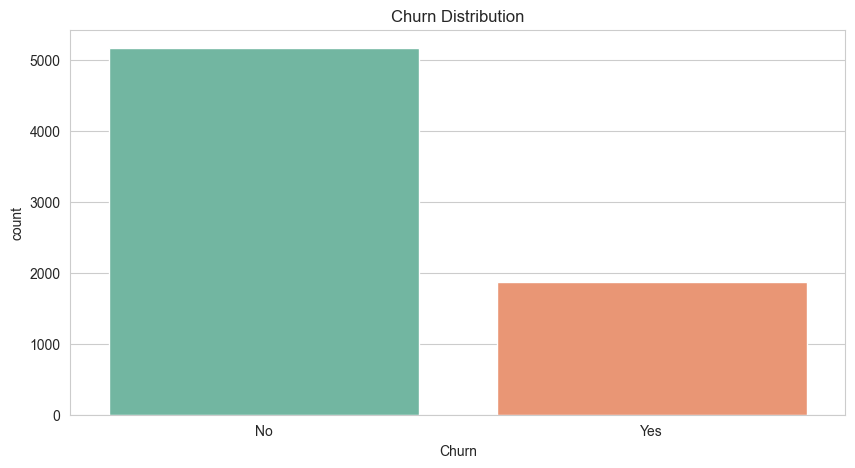

In [110]:
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

sns.countplot(x='Churn', data=df, palette='Set2')
plt.title("Churn Distribution")
plt.show()

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
6.2: Churn by Gender and Senior Citizen \(\downarrow\)</h3>


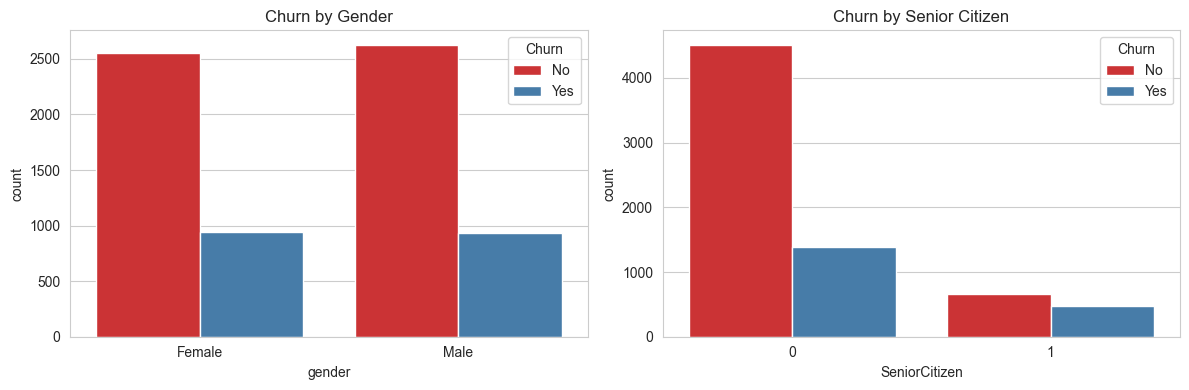

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='gender', hue='Churn', data=df, ax=axes[0], palette='Set1')
axes[0].set_title("Churn by Gender")

sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[1], palette='Set1')
axes[1].set_title("Churn by Senior Citizen")

plt.tight_layout()
plt.show()

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
6.3: Churn by Contract Type \(\downarrow\)</h3>


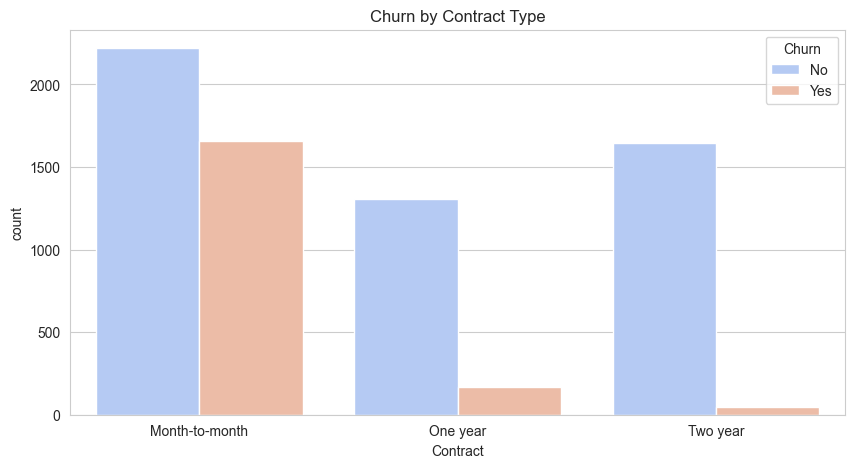

In [112]:
sns.countplot(x='Contract', hue='Churn', data=df, palette='coolwarm')
plt.title("Churn by Contract Type")
plt.show()

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
6.4: Tenure vs Churn \(\downarrow\)</h3>

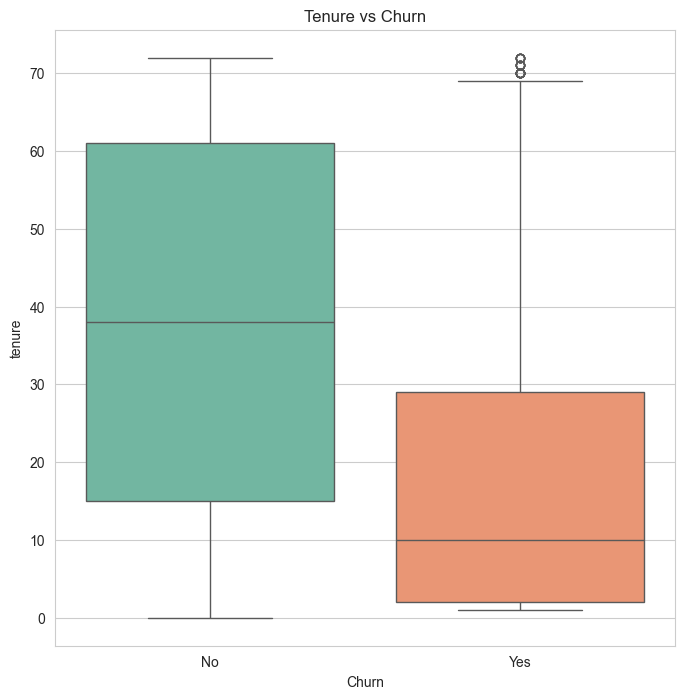

In [113]:
plt.figure(figsize = (8, 8))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title("Tenure vs Churn")
plt.show()

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
6.5: Monthly Charges vs Churn \(\downarrow\)</h3>

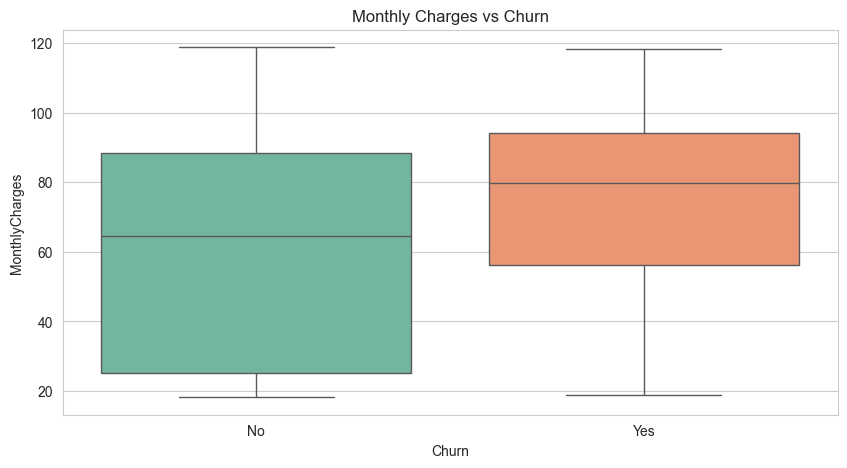

In [114]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title("Monthly Charges vs Churn")
plt.show()

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
6.7: Internet Service & Payment Method \(\downarrow\)</h3>

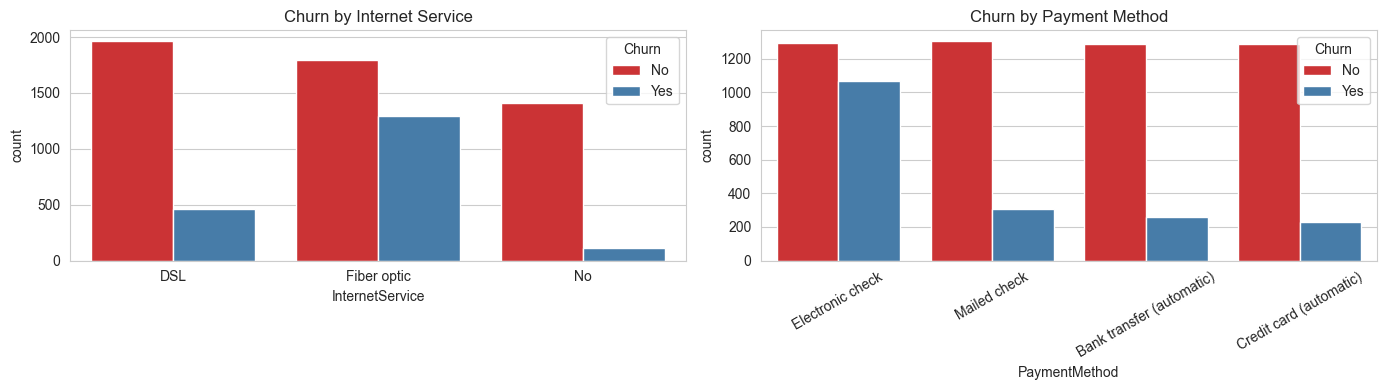

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0], palette='Set1')
axes[0].set_title("Churn by Internet Service")

sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1], palette='Set1')
axes[1].set_title("Churn by Payment Method")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
6.8: Correlation Heatmap (Numeric only) \(\downarrow\)</h1>

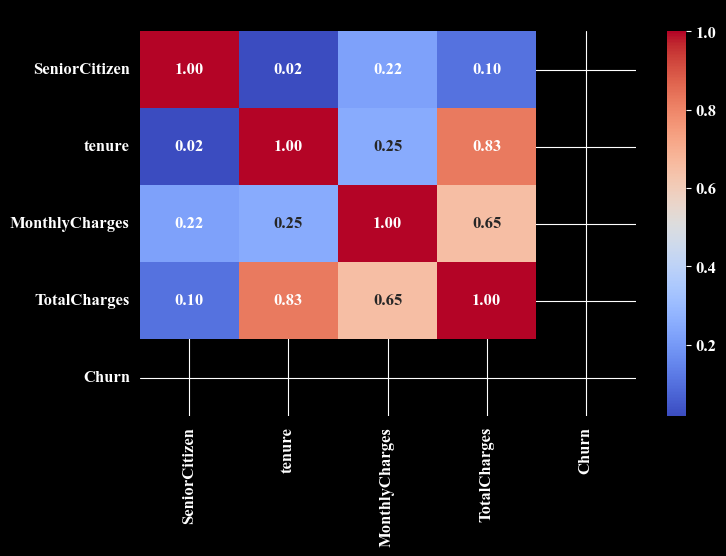

In [266]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
📝 EDA Summary: </h1>
Dataset imbalanced (26.5% churn)<br>
Month-to-month contract → high churn<br>
Low tenure → high churn<br>
High monthly charges → high churn<br>
Fiber optic + Electronic check → high churn

-----------------------------------------
<br>

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase -07: Data Cleaning \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
7.1: Remove Unnecessary Columns \(\downarrow\) </h1>

In [556]:
df = df.drop('customerID', axis=1)
print("After dropping customerID:", df.shape)

After dropping customerID: (7043, 20)


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
7.2: Fix TotalCharges \(\downarrow\) </h1>

In [557]:
df['TotalCharges'].dtypes

<StringDtype(na_value=nan)>

In [558]:
# TotalCharges object → numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing in TotalCharges: 11


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
7.3: Handling missing values \(\downarrow\) </h1>

In [559]:
df[df["TotalCharges"].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [560]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [561]:
df[df["TotalCharges"] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


***<u>Why I can fill the missing values with 0: </u> <br>Upon investigation, all missing TotalCharges values were associated with customers having zero tenure, while their MonthlyCharges values were available. This indicates that these customers had an active monthly service charge but had not accumulated any recorded total charges yet. Therefore, the missing TotalCharges values were replaced with 0 rather than using mean or median imputation, which could assign an unrealistic accumulated charge to these newly subscribed customers.***

In [562]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
7.4: Encoding the Target Variable \(\downarrow\) </h1>

In [563]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
7.5: Varify the clean data \(\downarrow\) </h1>

In [564]:
print("Missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)
df.head()

Missing values: 0
Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-08: Applying Statistical Testing \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
8.1: Contract vs Churn - Chi-Square Test \(\downarrow\) </h1>

In [565]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [566]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [567]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Contract"], df["Churn"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673391e-258


In [568]:
alpha = 0.05

if p_value < alpha:
    print("There is a statistically significant association between Contract and Churn.")
else:
    print("No statistically significant association was found.")

There is a statistically significant association between Contract and Churn.


In [569]:
n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
print("Cramer's V:", cramers_v)

Cramer's V: 0.4101156965761409


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
8.2: Tenure vs Churn - Mann-Shitney U Test \(\downarrow\) </h1>

In [570]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [571]:
from scipy.stats import mannwhitneyu

churned = df.loc[df["Churn"] == 1, "tenure"]
not_churned = df.loc[df["Churn"] == 0, "tenure"]

stat, p_value = mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 2515538.0
p-value: 2.419635517951866e-208


In [572]:
if p_value < 0.05:
    print("Tenure distributions differ significantly between churned and non-churned customers.")
else:
    print("No statistically significant difference was found.")

Tenure distributions differ significantly between churned and non-churned customers.


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
8.3: Monthly Charges -> Churn \(\downarrow\) </h1>

In [573]:
from scipy.stats import mannwhitneyu

churned = df.loc[df["Churn"] == 1, "MonthlyCharges"]
not_churned = df.loc[df["Churn"] == 0, "MonthlyCharges"]

stat, p_value = mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 6003125.5
p-value: 3.311627651988584e-54


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
8.4: Total Charges -> Churn \(\downarrow\) </h1>

In [574]:
churned = df.loc[df["Churn"] == 1, "TotalCharges"]
not_churned = df.loc[df["Churn"] == 0, "TotalCharges"]

stat, p_value = mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 3381224.0
p-value: 5.685033866207314e-83


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase- 09: Applying Feature Engineering Techniques \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
9.1: : Create New Features \(\downarrow\) </h1>

In [575]:
# 1. Avg charge per month
df['AvgChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# 2. Tenure group
df['TenureGroup'] = pd.cut(df['tenure'],
                            bins=[-1, 12, 24, 48, 72],
                            labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

# 3. Number of services
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

print("New features added!")
df[['AvgChargesPerMonth', 'TenureGroup', 'NumServices']].head()

New features added!


,AvgChargesPerMonth,TenureGroup,NumServices
0,14.925000,0-1yr,1
1,53.985714,2-4yr,3
2,36.050000,0-1yr,3
3,40.016304,2-4yr,3
4,50.550000,0-1yr,1


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
9.2: Drop TenureGroup (temporary, will encode) \(\downarrow\) </h1>

In [576]:
df['TenureGroup'] = df['TenureGroup'].astype(str)
print(df['TenureGroup'].value_counts())

TenureGroup
4-6yr    2239
0-1yr    2186
2-4yr    1594
1-2yr    1024
Name: count, dtype: int64


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-10: Applying Data Preprocessing Techniques \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
10.1: Separate X and y \(\downarrow\) </h1>

In [577]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 22)
y shape: (7043,)


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
10.2: Train Test Split \(\downarrow\) </h1>

In [578]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train: (5634, 22) | Test: (1409, 22)

Train churn rate: 0.265
Test churn rate: 0.265


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
10.3: Identifying Numerical and Categorical Features \(\downarrow\) </h1>

In [579]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

print(numeric_features)
print("\n", categorical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgChargesPerMonth', 'NumServices'],
      dtype='str')

 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TenureGroup'],
      dtype='str')


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
10.4: Building data Preprocessing Pipeline \(\downarrow\) </h1>

In [580]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

In [581]:
preprocessor = ColumnTransformer(
    transformers=[("numeric", StandardScaler(), numeric_features),
                  ("category", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

In [582]:
preprocessor.fit(X_train, y_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-11: Model Training \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
11.1: Building Baseline Model Pipeline, Training and Evaluation (Logistic Regression) \(\downarrow\) </h1>

In [583]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

In [584]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
11.2: Prediction \(\downarrow\) </h1>


In [585]:
y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
11.3: Evaluation Matrix \(\downarrow\) </h1>


In [586]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8048261178140526
Precision: 0.6677966101694915
Recall: 0.5267379679144385
F1: 0.5889387144992526
ROC-AUC: 0.8458136350719471


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
11.4: Classification Report \(\downarrow\) </h1>


In [587]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
11.5: Confusion Matrix \(\downarrow\) </h1>


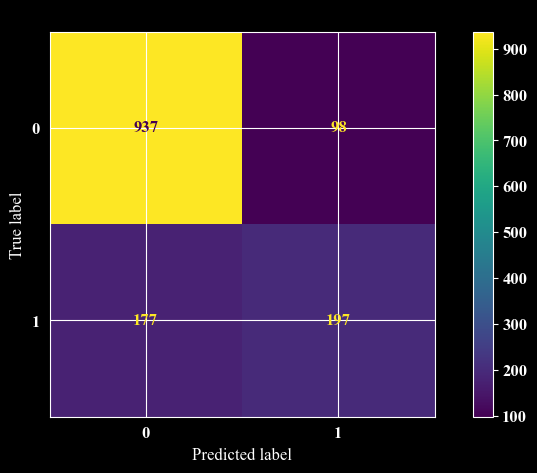

In [588]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")
plt.show()

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-12: Building multiple model pipeline, Train & Evaluate them \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
12.1: Decision Tree \(\downarrow\) </h1>


In [589]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
12.2: Random Forest \(\downarrow\) </h1>



In [590]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
12.3: XGBoost \(\downarrow\) </h1>



In [591]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    ))
])

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
12.4: Training All models \(\downarrow\) </h1>



In [592]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.804826,0.667797,0.526738,0.588939,0.845814
3,XGBoost,0.798439,0.651007,0.518717,0.577381,0.840761
1,Decision Tree,0.798439,0.634731,0.566845,0.598870,0.830176
2,Random Forest,0.779276,0.610526,0.465241,0.528073,0.819483


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
12.5: Cross Validation \(\downarrow\) </h1>



In [426]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

[0.82468938 0.80975433 0.83253155 0.82495395 0.84305403]
0.8269966499894863


In [593]:
index = np.arange(len(results_df.Model))
index

array([0, 1, 2, 3])

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
12.6: Visualization of Comapring model's performance \(\downarrow\) </h1>


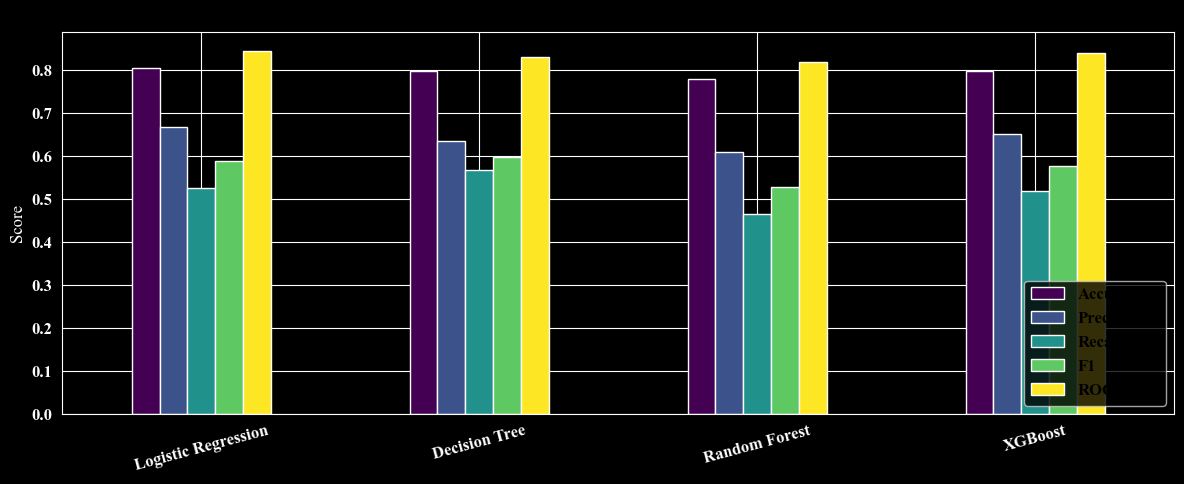

In [594]:
results_df.plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(index, results_df.Model, rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-13: Hyperparameter Tuning \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: skyblue; border-radius: 8px"; align = "Left">
13.1: Applying RandomizedSearchCV for Random Forest Model \(\downarrow\) </h1>

In [595]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [596]:
search = RandomizedSearchCV(
    rf_pipeline,
    param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [4, 6, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [200, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
13.1.1: Best Parameter \(\downarrow\) </h1>

In [597]:
best_model = search.best_estimator_

print(search.best_params_)

{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 8}


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
13.1.2: : Best Score \(\downarrow\) </h1>

In [598]:
print("Best CV F1:", search.best_score_)

Best CV F1: 0.8479164289284912


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
13.1.3: : Prediction \(\downarrow\) </h1>

In [599]:
final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(
    X_test
)[:, 1]
print(final_pred)
print(final_prob)

[0 1 0 ... 0 0 0]
[0.04827898 0.85158977 0.15676873 ... 0.24143421 0.08252424 0.03937024]


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
13.1.4: : Classification report \(\downarrow\) </h1>

In [600]:
print(
    classification_report(
        y_test,
        final_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        final_prob
    )
)

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409

ROC-AUC: 0.8428388746803068


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
13.1.5: : Customer Probability \(\downarrow\) </h1>

In [601]:
customer_probability = best_model.predict_proba(
    X_test
)[:, 1]
customer_probability

array([0.04827898, 0.85158977, 0.15676873, ..., 0.24143421, 0.08252424,
       0.03937024], shape=(1409,))

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
13.1.6: : Identifying Risk Customers \(\downarrow\) </h1>

In [602]:
def risk_level(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.70:
        return "Medium"

    else:
        return "High"

In [603]:
risk = [
    risk_level(p)
    for p in customer_probability
]

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: skyblue; border-radius: 8px"; align = "Left">
13.2: Applying GridSearchCV for XGBoost Model \(\downarrow\) </h1>

In [604]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

In [605]:
best_xgb = grid_search.best_estimator_

print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
0.5895730340889959


In [606]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("\n")
print(f"Confusion Matrix:  \n{confusion_matrix(y_test, y_pred)}")

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

F1 Score: 0.5889387144992526
ROC-AUC: 0.8458136350719471
PR-AUC: 0.6576677106249172


Confusion Matrix:  
[[937  98]
 [177 197]]


In [607]:
print("Best CV F1:", search.best_score_)

Best CV F1: 0.8479164289284912


In [608]:
best_model = search.best_estimator_

print(search.best_params_)

{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_depth': 8}


In [609]:
final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(
    X_test
)[:, 1]
print(final_pred)
print(final_prob)

[0 1 0 ... 0 0 0]
[0.04827898 0.85158977 0.15676873 ... 0.24143421 0.08252424 0.03937024]


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-14: Imbalance Handling \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
14.1: Checking dataset before balancing \(\downarrow\) </h1>

In [610]:
print("Before balancing:")
print(y_train.value_counts())

print("\nPercentage:")
print(y_train.value_counts(normalize=True) * 100)

Before balancing:
Churn
0    4139
1    1495
Name: count, dtype: int64

Percentage:
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64


In [611]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

In [612]:
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TenureGroup'],
      dtype='str')

In [613]:
categorical_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
14.2: Balancing dataset using SMOTENC \(\downarrow\) </h1>

In [614]:
from imblearn.over_sampling import SMOTENC

smotenc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_balanced, y_train_balanced = smotenc.fit_resample(
    X_train,
    y_train
)

In [615]:
print("After balancing:")
print(y_train_balanced.value_counts())

After balancing:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [616]:
print(
    y_train_balanced.value_counts(normalize=True) * 100
)

Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


In [617]:
X_train_balanced.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgChargesPerMonth,TenureGroup,NumServices
0,Male,0,No,No,35,No,No phone service,DSL,No,No,...,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,47.268056,2-4yr,3
1,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,...,No,No,Month-to-month,No,Mailed check,75.10,1151.55,71.971875,1-2yr,2
2,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,...,No,No,Two year,No,Mailed check,40.55,590.35,42.167857,1-2yr,3
3,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,70.581481,2-4yr,5
4,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,...,No,No,Month-to-month,No,Electronic check,44.55,44.55,22.275000,0-1yr,1


In [618]:
X_train_balanced[categorical_features].head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TenureGroup
0,Male,No,No,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,2-4yr
1,Male,Yes,Yes,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,1-2yr
2,Male,Yes,Yes,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,1-2yr
3,Female,Yes,No,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),2-4yr
4,Male,Yes,Yes,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,0-1yr


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-15: Preprocessing Balanced Data \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
15.1: Scaling Numeric Feature \(\downarrow\) </h1>

In [619]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(
    X_train_balanced[numeric_features]
)

X_test_num_scaled = scaler.transform(
    X_test[numeric_features]
)

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
15.2: Encoding the Categorical Features \(\downarrow\) </h1>

In [620]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat_encoded = encoder.fit_transform(
    X_train_balanced[categorical_features]
)

X_test_cat_encoded = encoder.transform(
    X_test[categorical_features]
)

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
15.3: Numerical + Categorical \(\downarrow\) </h1>

In [621]:
import numpy as np

X_train_final = np.hstack([
    X_train_num_scaled,
    X_train_cat_encoded
])

X_test_final = np.hstack([
    X_test_num_scaled,
    X_test_cat_encoded
])

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
15.4: Checking after Balancing X_train \(\downarrow\) </h1>

In [622]:
print("X_train:", X_train_final.shape)
print("X_test :", X_test_final.shape)

print("y_train:", y_train_balanced.shape)
print("y_test :", y_test.shape)

X_train: (8278, 51)
X_test : (1409, 51)
y_train: (8278,)
y_test : (1409,)


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-16: Training Model on Balanced Data \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: skyblue; border-radius: 8px"; align = "Left">
16.1: Training Random Forest model on balanced data \(\downarrow\) </h1>

In [623]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(
    X_train_final,
    y_train_balanced
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
16.1.1: Prediction \(\downarrow\) </h1>

In [624]:
y_pred = rf_balanced.predict(X_test_final)
y_prob = rf_balanced.predict_proba(X_test_final)[:, 1]
print(y_pred)
print(y_prob)

[0 1 0 ... 0 0 0]
[0.   0.69 0.04 ... 0.08 0.04 0.  ]


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
16.1.2: Evaluation \(\downarrow\) </h1>

In [625]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.55      0.58      0.57       374

    accuracy                           0.77      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.77      0.77      1409

F1 Score: 0.5673202614379085
ROC-AUC: 0.8175114314500505
PR-AUC: 0.5912083714089422


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
16.1.3: Confution Matrix \(\downarrow\) </h1>

In [626]:
print(confusion_matrix(y_test, y_pred))

[[861 174]
 [157 217]]


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: skyblue; border-radius: 8px"; align = "Left">
16.2: Training XGBoost model on balanced data \(\downarrow\) </h1>

In [627]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_balanced = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_balanced.fit(X_train_final, y_train_balanced)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
16.2.1: Prediction \(\downarrow\) </h1>

In [628]:
y_pred = xgb_balanced.predict(X_test_final)
y_prob = xgb_balanced.predict_proba(X_test_final)[:, 1]
print(y_pred)
print(y_prob)

[0 1 0 ... 0 0 0]
[0.0013154  0.9536703  0.32128018 ... 0.04714601 0.32137388 0.0024372 ]


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
16.2.2: Evaluation Matrix \(\downarrow\) </h1>

In [629]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1035
           1       0.54      0.60      0.57       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409

F1 Score: 0.5710659898477157
ROC-AUC: 0.8141194554238032
PR-AUC: 0.6073536911589593
[[846 189]
 [149 225]]


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
16.2.3: Confusion Matrix \(\downarrow\) </h1>

In [630]:
print(confusion_matrix(y_test, y_pred))

[[846 189]
 [149 225]]


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px"; align = "Left">
Phase-17: Hyperparameter Tuning on Balanced Data \(\downarrow\) \(\downarrow\)</h3>

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: skyblue; border-radius: 8px"; align = "Left">
17.1: Applying RandomizedSearchCV on Balanced Data for Random Forest Model  \(\downarrow\) </h1>

In [631]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

In [632]:
rf_balanced_search = RandomizedSearchCV(
    estimator=rf_balanced,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [633]:
rf_balanced_search.fit(
    X_train_final,
    y_train_balanced
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
17.1.1: Best Parameter \(\downarrow\) </h1>

In [634]:
print("Best Parameters:")
print(rf_balanced_search.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
17.1.2: Best CV F1 \(\downarrow\) </h1>

In [635]:
print("Best CV F1:", rf_balanced_search.best_score_)

Best CV F1: 0.8317714706551295


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
17.1.3: Test dataset Evaluation using Tuned Model after Balancing \(\downarrow\) </h1>

In [636]:
best_rf = rf_balanced_search.best_estimator_

y_pred_balanced = best_rf.predict(X_test_final)

y_prob_balanced = best_rf.predict_proba(
    X_test_final
)[:, 1]

print(y_pred_balanced)
print(y_prob_balanced)

[0 1 0 ... 0 0 0]
[0.01039084 0.72865714 0.07636953 ... 0.18090824 0.0442812  0.01338313]


In [637]:
print(classification_report(
    y_test,
    y_pred_balanced
))

              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1035
           1       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [638]:
print("F1 Score:",
      f1_score(y_test, y_pred_balanced))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_balanced))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_balanced))

F1 Score: 0.5898389095415117
ROC-AUC: 0.8280322405642099
PR-AUC: 0.619009439957927


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
17.1.4: Confution Matrix \(\downarrow\) </h1>

In [639]:
print(confusion_matrix(
    y_test,
    y_pred_balanced
))

[[840 195]
 [136 238]]


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: skyblue; border-radius: 8px"; align = "Left">
17.2: Applying RandomizedSearchCV on Balanced Data for XGBoost model \(\downarrow\) </h1>

In [640]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

xgb_balanced_search = RandomizedSearchCV(
    estimator=xgb_balanced,
    param_distributions=param_grid,
    n_iter=40,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_balanced_search.fit(
    X_train_final,
    y_train_balanced
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
17.2.1: Best Parameter \(\downarrow\) </h1>

In [641]:
print("Best Parameters:")
print(xgb_balanced_search.best_params_)

print("Best CV F1:")
print(xgb_balanced_search.best_score_)

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV F1:
0.8368863860693059


In [642]:
best_xgb = xgb_balanced_search.best_estimator_

y_pred_xgb = xgb_balanced_search.predict(X_test_final)
y_prob_xgb = xgb_balanced_search.predict_proba(X_test_final)[:, 1]

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
17.2.2: Evaluation Matrix after tuning XGBoost on Balanced data \(\downarrow\) </h1>

In [643]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print(classification_report(y_test, y_pred_xgb))

print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

print("Confusion Matrix:")

              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1035
           1       0.58      0.63      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.78      0.78      1409

F1: 0.6
ROC-AUC: 0.8189167893771474
PR-AUC: 0.614064513472585
Confusion Matrix:


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
17.2.3: Confution Matrix \(\downarrow\) </h1>

In [644]:
print(confusion_matrix(y_test, y_pred_xgb))

[[863 172]
 [140 234]]


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px" align="Left">
Phase-18: Comparing Models Trained on Imbalanced and Balanced Data ↓ ↓</h3>


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px" align="Left">
18.1: Collecting Model Evaluation Metrics ↓</h1>


In [645]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px" align="Left">
18.2: Imbalanced vs Balanced Model Comparison ↓</h1>


In [646]:
# Baseline models from the imbalanced training dataset
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "XGBoost",
        "Random Forest"
    ],
    "Training Data": [
        "Imbalanced",
        "Imbalanced",
        "Imbalanced",
        "Imbalanced"
    ],
    "Accuracy": [0.804826, 0.798439, 0.798439, 0.779276],
    "Precision": [0.667797, 0.634731, 0.651007, 0.610526],
    "Recall": [0.526738, 0.566845, 0.518717, 0.465241],
    "F1": [0.588939, 0.598870, 0.577381, 0.528073],
    "ROC-AUC": [0.845814, 0.830176, 0.840761, 0.819483],
    "PR-AUC": [np.nan, np.nan, np.nan, np.nan]
})

# Tuned XGBoost on the original imbalanced training data
tuned_xgb_imbalanced = evaluate_model(
    y_test,
    grid_search.predict(X_test),
    grid_search.predict_proba(X_test)[:, 1]
)

# Tuned Random Forest after balancing
tuned_rf_balanced = evaluate_model(
    y_test,
    y_pred_balanced,
    y_prob_balanced
)

# Tuned XGBoost after balancing
tuned_xgb_balanced = evaluate_model(
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

tuned_results = pd.DataFrame([
    {
        "Model": "Tuned XGBoost",
        "Training Data": "Imbalanced",
        **tuned_xgb_imbalanced
    },
    {
        "Model": "Tuned Random Forest",
        "Training Data": "Balanced",
        **tuned_rf_balanced
    },
    {
        "Model": "Tuned XGBoost",
        "Training Data": "Balanced",
        **tuned_xgb_balanced
    }
])

model_comparison = pd.concat(
    [baseline_results, tuned_results],
    ignore_index=True
)

model_comparison.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)


,Model,Training Data,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned XGBoost,Balanced,0.778566,0.576355,0.625668,0.600000,0.818917,0.614065
1,Decision Tree,Imbalanced,0.798439,0.634731,0.566845,0.598870,0.830176,NaN
2,Tuned Random Forest,Balanced,0.765082,0.549654,0.636364,0.589839,0.828032,0.619009
3,Logistic Regression,Imbalanced,0.804826,0.667797,0.526738,0.588939,0.845814,NaN
4,Tuned XGBoost,Imbalanced,0.800568,0.651466,0.534759,0.587372,0.843030,0.651549
5,XGBoost,Imbalanced,0.798439,0.651007,0.518717,0.577381,0.840761,NaN
6,Random Forest,Imbalanced,0.779276,0.610526,0.465241,0.528073,0.819483,NaN


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px" align="Left">
18.3: Direct Comparison of Tuned XGBoost Before and After Balancing ↓</h1>


In [647]:
xgb_comparison = tuned_results[
    tuned_results["Model"] == "Tuned XGBoost"
].copy()

xgb_comparison.sort_values(
    "Training Data"
).reset_index(drop=True)


,Model,Training Data,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned XGBoost,Balanced,0.778566,0.576355,0.625668,0.600000,0.818917,0.614065
1,Tuned XGBoost,Imbalanced,0.800568,0.651466,0.534759,0.587372,0.843030,0.651549


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px" align="Left">
18.4: Performance Change After Balancing ↓</h1>


In [648]:
imbalanced_xgb = xgb_comparison[
    xgb_comparison["Training Data"] == "Imbalanced"
].iloc[0]

balanced_xgb = xgb_comparison[
    xgb_comparison["Training Data"] == "Balanced"
].iloc[0]

performance_change = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    "Imbalanced XGBoost": [
        imbalanced_xgb["Accuracy"],
        imbalanced_xgb["Precision"],
        imbalanced_xgb["Recall"],
        imbalanced_xgb["F1"],
        imbalanced_xgb["ROC-AUC"],
        imbalanced_xgb["PR-AUC"]
    ],
    "Balanced XGBoost": [
        balanced_xgb["Accuracy"],
        balanced_xgb["Precision"],
        balanced_xgb["Recall"],
        balanced_xgb["F1"],
        balanced_xgb["ROC-AUC"],
        balanced_xgb["PR-AUC"]
    ]
})

performance_change["Change"] = (
    performance_change["Balanced XGBoost"]
    - performance_change["Imbalanced XGBoost"]
)

performance_change


,Metric,Imbalanced XGBoost,Balanced XGBoost,Change
0,Accuracy,0.800568,0.778566,-0.022001
1,Precision,0.651466,0.576355,-0.075111
2,Recall,0.534759,0.625668,0.090909
3,F1,0.587372,0.600000,0.012628
4,ROC-AUC,0.843030,0.818917,-0.024113
5,PR-AUC,0.651549,0.614065,-0.037484


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px" align="Left">
18.5: Final Model Candidate ↓</h1>


In [649]:
# Final candidates are compared using F1 as the primary metric,
# with Recall and PR-AUC used to understand the trade-off.

final_candidates = tuned_results[
    tuned_results["Model"].isin([
        "Tuned XGBoost",
        "Tuned Random Forest"
    ])
].copy()

final_candidates.sort_values(
    ["F1", "Recall", "PR-AUC"],
    ascending=False
).reset_index(drop=True)


,Model,Training Data,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned XGBoost,Balanced,0.778566,0.576355,0.625668,0.600000,0.818917,0.614065
1,Tuned Random Forest,Balanced,0.765082,0.549654,0.636364,0.589839,0.828032,0.619009
2,Tuned XGBoost,Imbalanced,0.800568,0.651466,0.534759,0.587372,0.843030,0.651549


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px" align="Left">
18.6: Threshold Analysis for the Final Candidate ↓</h1>

The default classification threshold of 0.50 is not assumed to be optimal for customer churn prediction. The threshold is selected using out-of-fold predictions from the balanced training data, while the test set remains untouched until final evaluation.

In [650]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold probabilities are used to select the operating threshold.
oof_prob_xgb = cross_val_predict(
    xgb_balanced_search.best_estimator_,
    X_train_final,
    y_train_balanced,
    cv=cv_threshold,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.20, 0.71, 0.05)
threshold_results = []

for threshold in thresholds:
    oof_pred = (oof_prob_xgb >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(y_train_balanced, oof_pred),
        "Recall": recall_score(y_train_balanced, oof_pred),
        "F1": f1_score(y_train_balanced, oof_pred)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df.sort_values("F1", ascending=False).reset_index(drop=True)

,Threshold,Precision,Recall,F1
0,0.45,0.831312,0.877507,0.853785
1,0.40,0.817335,0.890795,0.852486
2,0.50,0.842715,0.860836,0.851679
3,0.55,0.856406,0.842957,0.849629
4,0.35,0.801332,0.901425,0.848437
5,0.30,0.787093,0.916405,0.846841
6,0.60,0.870031,0.824837,0.846831
7,0.65,0.882275,0.805750,0.842278
8,0.25,0.766820,0.928002,0.839746
9,0.20,0.749614,0.939599,0.833923


In [651]:
# Select the threshold with the highest out-of-fold F1-score.
best_threshold = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax(),
    "Threshold"
]

print(f"Selected threshold: {best_threshold:.2f}")

Selected threshold: 0.45


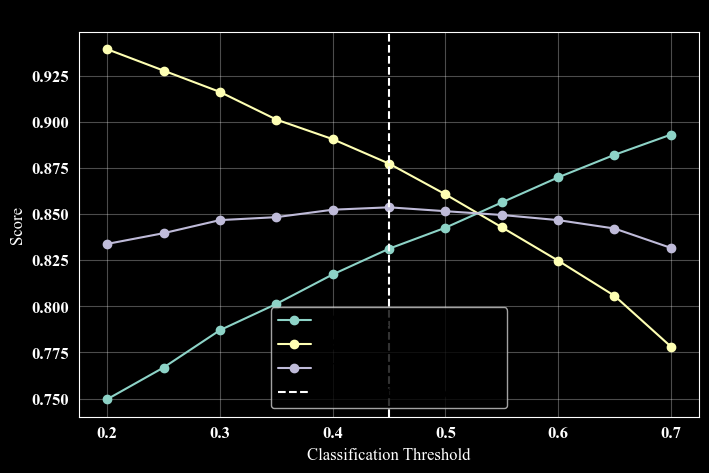

In [652]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1"], marker="o", label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Selected threshold = {best_threshold:.2f}")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Balanced Tuned XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Threshold Selection Interpretation

The selected threshold maximizes F1-score on out-of-fold training predictions. This threshold balances Precision and Recall according to the project's F1-based model selection objective. The untouched test set is used only once for the final evaluation below.

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px" align="Left">
18.7: Final Test Evaluation of the Selected Candidate ↓</h1>

In [653]:
# Final candidate: Balanced Tuned XGBoost
final_model = xgb_balanced_search.best_estimator_

# The test set remains untouched during threshold selection.
final_y_prob = final_model.predict_proba(X_test_final)[:, 1]
final_y_pred = (final_y_prob >= best_threshold).astype(int)

print("Final Model: Balanced Tuned XGBoost")
print(f"Selected Threshold: {best_threshold:.2f}")
print()
print(classification_report(y_test, final_y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_y_pred))

print("ROC-AUC:", roc_auc_score(y_test, final_y_prob))
print("PR-AUC:", average_precision_score(y_test, final_y_prob))

Final Model: Balanced Tuned XGBoost
Selected Threshold: 0.45

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.55      0.66      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

Confusion Matrix:
[[837 198]
 [129 245]]
ROC-AUC: 0.8189167893771474
PR-AUC: 0.614064513472585


### Phase-18 Conclusion

The models were evaluated on the same untouched test set, and balancing was applied only to the training data. The Balanced Tuned XGBoost model is retained as the final candidate based on the current model comparison. A classification threshold was then selected using 5-fold out-of-fold predictions from the balanced training data. The selected threshold was applied only after the threshold-selection step to the untouched test set. Final performance is reported using Precision, Recall, F1-score, ROC-AUC, PR-AUC, and the Confusion Matrix.

In [654]:
final_model = xgb_balanced_search

In [656]:
final_model

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [657]:
best_model = final_model

<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px" align="Left">
Phase-19: Save the best model ↓ ↓</h3>


In [658]:
import joblib
from pathlib import Path

# Create models folder
Path("models").mkdir(exist_ok=True)

# 1. Save trained model
joblib.dump(best_model, "models/churn_model.pkl")

# 2. Save scaler
joblib.dump(scaler, "models/scaler.pkl")

# 3. Save OneHotEncoder
joblib.dump(encoder, "models/encoder.pkl")

# 4. Create exact feature names
categorical_feature_names = encoder.get_feature_names_out(
    categorical_features
)

feature_names = list(numeric_features) + list(categorical_feature_names)

# 5. Save feature names
joblib.dump(feature_names, "models/feature_names.pkl")

print("\n✅ Final model artifacts saved:")
print("   - models/churn_model.pkl")
print("   - models/scaler.pkl")
print("   - models/encoder.pkl")
print("   - models/feature_names.pkl")

print(f"\n✅ Total features: {len(feature_names)}")
print(f"✅ X_train_final shape: {X_train_final.shape}")


✅ Final model artifacts saved:
   - models/churn_model.pkl
   - models/scaler.pkl
   - models/encoder.pkl
   - models/feature_names.pkl

✅ Total features: 51
✅ X_train_final shape: (8278, 51)


In [660]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)

joblib.dump(
    best_model,
    "models/churn_pipeline.pkl"
)

print("✅ churn_pipeline.pkl saved")

✅ churn_pipeline.pkl saved


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px" align="Left">
Phase-20: SHAP Explainability ↓ ↓</h3>


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.0 — Final Model Setup \(\downarrow\) </h1>

In [661]:
# Final model selected after hyperparameter tuning
# Extract the best fitted model selected by RandomizedSearchCV
final_xgb_model = final_model.best_estimator_

print("Final Model:", type(final_model).__name__)
print("Selected Estimator:", type(final_xgb_model).__name__)
print("\nBest Parameters:")
print(final_model.best_params_)

Final Model: RandomizedSearchCV
Selected Estimator: XGBClassifier

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.0.1 — Extract Final XGBoost Estimator \(\downarrow\) </h1>

In [662]:
xgb_model = final_xgb_model

print("Final XGBoost Model:")
print(xgb_model)

Final XGBoost Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.1 — Select a Customer's Data \(\downarrow\) </h1>

In [663]:
customer_idx = 0

customer_data = X_test_final[
    customer_idx:customer_idx + 1
]

customer_probability = float(
    xgb_model.predict_proba(customer_data)[0, 1]
)

customer_prediction = int(
    customer_probability >= best_threshold
)

print(
    "Prediction:",
    "Churn" if customer_prediction == 1 else "No Churn"
)

print(
    f"Churn Probability: {customer_probability:.2%}"
)

print(
    f"Decision Threshold: {best_threshold:.2f}"
)

Prediction: No Churn
Churn Probability: 0.31%
Decision Threshold: 0.45


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.2 — Create SHAP Explainer for Final XGBoost \(\downarrow\) </h1>

In [664]:
import shap
import numpy as np

# SHAP explainer for the FINAL tuned XGBoost model
explainer = shap.TreeExplainer(xgb_model)

print("SHAP Explainer created successfully.")
print("Explained model:", type(xgb_model).__name__)

SHAP Explainer created successfully.
Explained model: XGBClassifier


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.3 — Calculate SHAP Values \(\downarrow\) </h1>

In [665]:
shap_values = explainer.shap_values(X_test_final)

shap_values = np.asarray(shap_values)

print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test_final.shape)

SHAP values shape: (1409, 51)
Test data shape: (1409, 51)


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.4 — Verify SHAP Feature Dimensions \(\downarrow\) </h1>

In [666]:
print("Number of model features:", X_test_final.shape[1])
print("Number of SHAP features:", shap_values.shape[1])

assert X_test_final.shape[1] == shap_values.shape[1]

print("✅ SHAP feature dimensions matched!")

Number of model features: 51
Number of SHAP features: 51
✅ SHAP feature dimensions matched!


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.5 — Get Feature Names \(\downarrow\) </h1>

In [667]:
feature_names = list(feature_names)

print("Number of feature names:", len(feature_names))
print("Number of model features:", X_test_final.shape[1])

assert len(feature_names) == X_test_final.shape[1]

print("✅ Feature names matched!")

Number of feature names: 51
Number of model features: 51
✅ Feature names matched!


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.6 — Global SHAP Summary Plot \(\downarrow\) </h1>

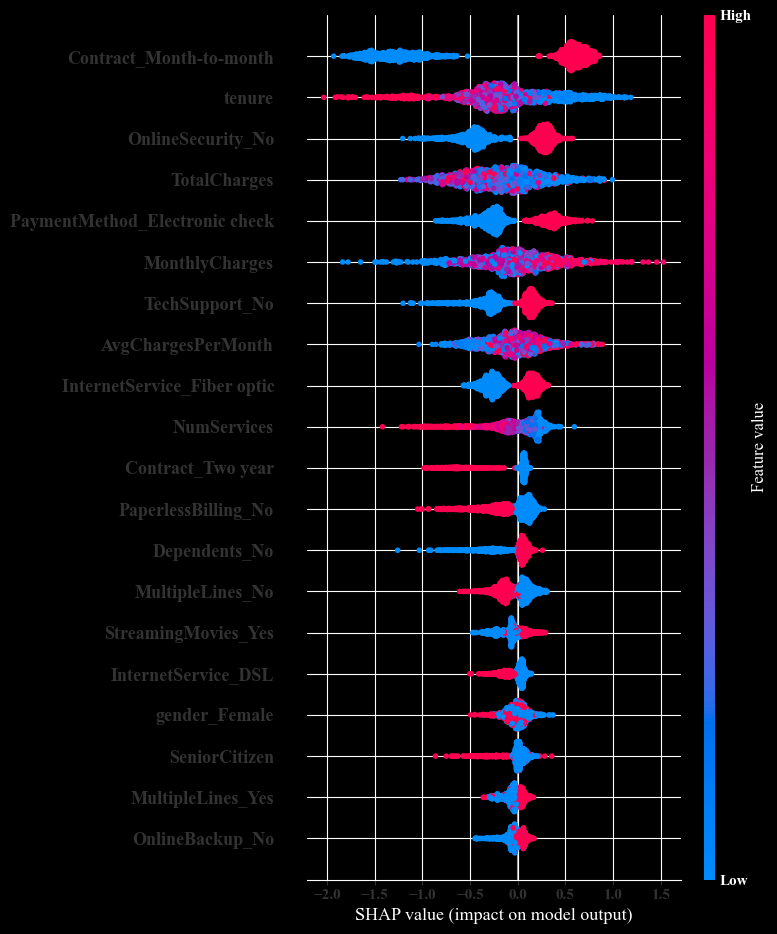

In [668]:
shap.summary_plot(
    shap_values,
    X_test_final,
    feature_names=feature_names
)

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.7 — SHAP Feature Importance \(\downarrow\) </h1>

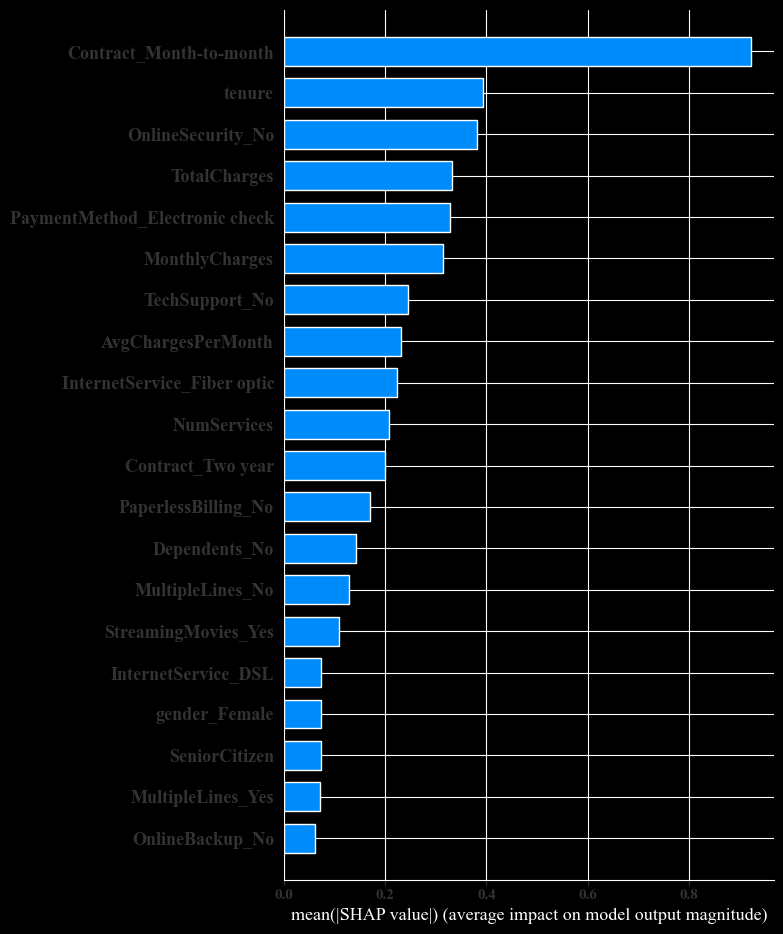

In [669]:
shap.summary_plot(
    shap_values,
    X_test_final,
    feature_names=feature_names,
    plot_type="bar"
)

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.8 — Select One Customer for Local Explanation \(\downarrow\) </h1>

In [670]:
customer_idx = 0

customer_transformed = X_test_final[
    customer_idx:customer_idx + 1
]

print("Customer shape:", customer_transformed.shape)

Customer shape: (1, 51)


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.9 — Customer Prediction \(\downarrow\) </h1>

In [671]:
customer_probability = float(
    xgb_model.predict_proba(customer_transformed)[0, 1]
)

customer_prediction = int(
    customer_probability >= best_threshold
)

print(
    "Prediction:",
    "Churn" if customer_prediction == 1 else "No Churn"
)

print(
    f"Churn Probability: {customer_probability:.2%}"
)

print(
    f"Decision Threshold: {best_threshold:.2f}"
)

Prediction: No Churn
Churn Probability: 0.31%
Decision Threshold: 0.45


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.10 — Customer SHAP Values \(\downarrow\) </h1>

In [672]:
customer_shap_values = np.asarray(
    explainer.shap_values(customer_transformed)
)

print("Customer SHAP shape:", customer_shap_values.shape)

Customer SHAP shape: (1, 51)


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.11 — Extract Customer SHAP Values \(\downarrow\) </h1>

In [673]:
customer_shap_values_one = customer_shap_values[0]

print(
    "Number of customer SHAP values:",
    len(customer_shap_values_one)
)

print(
    "Number of features:",
    len(feature_names)
)

assert len(customer_shap_values_one) == len(feature_names)

print("✅ Customer SHAP dimensions matched!")

Number of customer SHAP values: 51
Number of features: 51
✅ Customer SHAP dimensions matched!


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.12 — Customer SHAP Waterfall Plot \(\downarrow\) </h1>

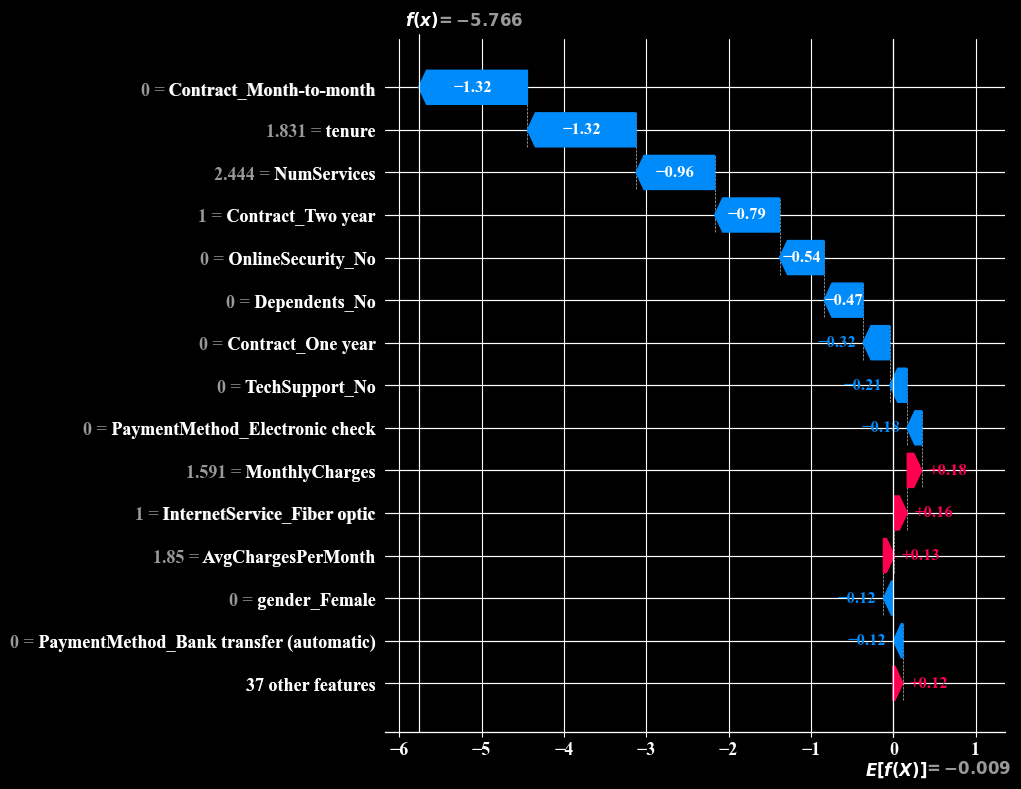

In [674]:
base_value = explainer.expected_value

if np.ndim(base_value) > 0:
    base_value = np.asarray(base_value).reshape(-1)[0]

base_value = float(base_value)

customer_explanation = shap.Explanation(
    values=customer_shap_values_one,
    base_values=base_value,
    data=customer_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.13 — Verify Raw → Transformed Inference Flow \(\downarrow\) </h1>

In [675]:
customer_raw = X_test.iloc[[0]].copy()

customer_num_scaled = scaler.transform(
    customer_raw[numeric_features]
)

customer_cat_encoded = encoder.transform(
    customer_raw[categorical_features]
)

customer_transformed = np.hstack([
    customer_num_scaled,
    customer_cat_encoded
])

print("Raw customer shape:", customer_raw.shape)
print("Transformed customer shape:", customer_transformed.shape)

Raw customer shape: (1, 22)
Transformed customer shape: (1, 51)


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.14 — Verify Prediction After Transformation \(\downarrow\) </h1>

In [676]:
probability = float(
    xgb_model.predict_proba(customer_transformed)[0, 1]
)

prediction = int(
    probability >= best_threshold
)

print(
    "Prediction:",
    "Churn" if prediction == 1 else "No Churn"
)

print(f"Churn Probability: {probability:.2%}")
print(f"Decision Threshold: {best_threshold:.2f}")

Prediction: No Churn
Churn Probability: 0.31%
Decision Threshold: 0.45


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.15 — Reusable Transformation Function \(\downarrow\) </h1>

In [677]:
def transform_customer(customer_df):
    """
    Transform raw customer data using the
    same scaler and encoder used during training.
    """

    customer_num_scaled = scaler.transform(
        customer_df[numeric_features]
    )

    customer_cat_encoded = encoder.transform(
        customer_df[categorical_features]
    )

    customer_transformed = np.hstack([
        customer_num_scaled,
        customer_cat_encoded
    ])

    return customer_transformed

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.16 — Reusable Prediction Function \(\downarrow\) </h1>

In [678]:
def predict_customer(customer_df):
    """
    Predict churn for a raw customer using
    the final tuned XGBoost model.
    """

    transformed_data = transform_customer(
        customer_df
    )

    probability = float(
        xgb_model.predict_proba(
            transformed_data
        )[0, 1]
    )

    prediction = int(
        probability >= best_threshold
    )

    return {
        "prediction": prediction,
        "label": (
            "Churn"
            if prediction == 1
            else "No Churn"
        ),
        "churn_probability": probability,
        "threshold": float(best_threshold)
    }

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.17 — Test Reusable Prediction Function \(\downarrow\) </h1>

In [679]:
result = predict_customer(
    X_test.iloc[[0]]
)

print("Prediction:", result["label"])
print(
    f"Churn Probability: "
    f"{result['churn_probability']:.2%}"
)
print(
    f"Decision Threshold: "
    f"{result['threshold']:.2f}"
)

Prediction: No Churn
Churn Probability: 0.31%
Decision Threshold: 0.45


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.18 — Create a New Customer \(\downarrow\) </h1>

In [680]:
new_customer = create_customer(
    gender="Female",
    SeniorCitizen=0,
    Partner="Yes",
    Dependents="No",
    tenure=12,
    PhoneService="Yes",
    MultipleLines="No",
    InternetService="Fiber optic",
    OnlineSecurity="No",
    OnlineBackup="No",
    DeviceProtection="No",
    TechSupport="No",
    StreamingTV="Yes",
    StreamingMovies="Yes",
    Contract="Month-to-month",
    PaperlessBilling="Yes",
    PaymentMethod="Electronic check",
    MonthlyCharges=80.50,
    TotalCharges=966.00
)

new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgChargesPerMonth,TenureGroup,NumServices
0,Female,0,Yes,No,12,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,80.5,966.0,74.307692,0-1yr,3


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.19 — Transform New Customer \(\downarrow\) </h1>

In [681]:
new_customer_transformed = transform_customer(
    new_customer
)

print("Raw shape:", new_customer.shape)
print(
    "Transformed shape:",
    new_customer_transformed.shape
)

print(
    "Expected features:",
    len(feature_names)
)

assert (
    new_customer_transformed.shape[1]
    == len(feature_names)
)

print(
    "✅ New customer transformation "
    "matches the trained feature space."
)

Raw shape: (1, 22)
Transformed shape: (1, 51)
Expected features: 51
✅ New customer transformation matches the trained feature space.


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.20 — Predict New Customer \(\downarrow\) </h1>

In [682]:
new_probability = float(
    xgb_model.predict_proba(
        new_customer_transformed
    )[0, 1]
)

new_prediction = int(
    new_probability >= best_threshold
)

print(
    "Prediction:",
    "Churn"
    if new_prediction == 1
    else "No Churn"
)

print(
    f"Churn Probability: "
    f"{new_probability:.2%}"
)

print(
    f"Decision Threshold: "
    f"{best_threshold:.2f}"
)

Prediction: Churn
Churn Probability: 76.52%
Decision Threshold: 0.45


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.21 — SHAP Explanation for New Customer \(\downarrow\) </h1>

In [683]:
new_customer_shap = np.asarray(
    explainer.shap_values(
        new_customer_transformed
    )
)

print(
    "New customer SHAP shape:",
    new_customer_shap.shape
)

New customer SHAP shape: (1, 51)


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.22 — New Customer SHAP Waterfall \(\downarrow\) </h1>

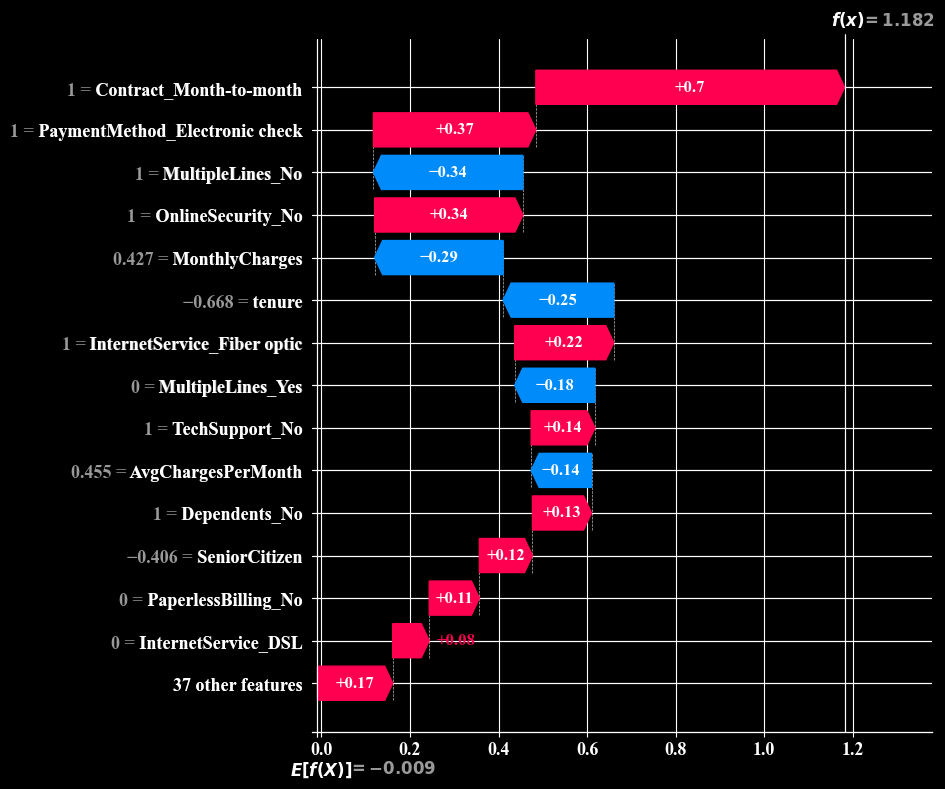

In [684]:
new_customer_shap_values = new_customer_shap[0]

base_value = explainer.expected_value

if np.ndim(base_value) > 0:
    base_value = np.asarray(
        base_value
    ).reshape(-1)[0]

base_value = float(base_value)

new_customer_explanation = shap.Explanation(
    values=new_customer_shap_values,
    base_values=base_value,
    data=new_customer_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(
    new_customer_explanation,
    max_display=15
)

<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.23 — Save Final Model Bundle \(\downarrow\) </h1>

In [685]:
import joblib
from pathlib import Path

Path("models").mkdir(
    exist_ok=True
)

deployment_bundle = {
    "model": xgb_model,
    "scaler": scaler,
    "encoder": encoder,
    "feature_names": feature_names,
    "threshold": float(best_threshold)
}

joblib.dump(
    deployment_bundle,
    "models/churn_pipeline.pkl"
)

print(
    "✅ Final XGBoost deployment bundle saved:"
)

print(
    "models/churn_pipeline.pkl"
)

✅ Final XGBoost deployment bundle saved:
models/churn_pipeline.pkl


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.24 — Load & Verify Saved Model \(\downarrow\) </h1>

In [686]:
loaded_bundle = joblib.load(
    "models/churn_pipeline.pkl"
)

loaded_model = loaded_bundle["model"]
loaded_scaler = loaded_bundle["scaler"]
loaded_encoder = loaded_bundle["encoder"]
loaded_feature_names = loaded_bundle["feature_names"]
loaded_threshold = loaded_bundle["threshold"]

print(
    "Loaded Model:",
    type(loaded_model).__name__
)

print(
    "Loaded Threshold:",
    loaded_threshold
)

print(
    "Loaded Feature Count:",
    len(loaded_feature_names)
)

Loaded Model: XGBClassifier
Loaded Threshold: 0.45
Loaded Feature Count: 51


<h1 style="background-color: #111; padding: 15px; font: bold 30px arial; color: blue; border-radius: 8px"; align = "Left">
20.25 — Final Verification \(\downarrow\) </h1>

In [687]:
loaded_num_scaled = loaded_scaler.transform(
    new_customer[numeric_features]
)

loaded_cat_encoded = loaded_encoder.transform(
    new_customer[categorical_features]
)

loaded_transformed = np.hstack([
    loaded_num_scaled,
    loaded_cat_encoded
])

loaded_probability = float(
    loaded_model.predict_proba(
        loaded_transformed
    )[0, 1]
)

loaded_prediction = int(
    loaded_probability >= loaded_threshold
)

print(
    "Final Loaded Model Prediction:",
    "Churn"
    if loaded_prediction == 1
    else "No Churn"
)

print(
    f"Final Loaded Model Probability: "
    f"{loaded_probability:.2%}"
)

print(
    f"Final Decision Threshold: "
    f"{loaded_threshold:.2f}"
)

print(
    "\n✅ Final model verification completed."
)

Final Loaded Model Prediction: Churn
Final Loaded Model Probability: 76.52%
Final Decision Threshold: 0.45

✅ Final model verification completed.


<h3 style="background-color: #111; padding: 15px; font: bold 30px arial; color: lightgreen; border-radius: 8px" align="Left">
Phase-21: Development Machine Learning App using Streamlit ↓ ↓</h3>
